In [91]:
import pandas as pd

df1 = pd.read_csv('csvs/tcga_lung_subset.csv.zip').iloc[:, :10]
df1['slide_id'] = df1['slide_id'].str.rstrip('.svs')

for fold in range(10):
    for split in ['train', 'val', 'test']:

        fl = 'csvs/tcga-nsclc/%s_%d.csv'%(split, fold)

        split_file = pd.read_csv('csvs/tcga-nsclc/splits/splits_%d_bool.csv'%fold)
        df_split = split_file.loc[split_file[split]==True]
        df2 = df_split.rename(columns={df_split.columns[0]:'slide_id'})

        df = pd.merge(df1, df2, on='slide_id')

        df['oncotree_code'] = df['oncotree_code'].replace('LUAD', 0).replace('LUSC', 1)

        df = df.rename(columns={'oncotree_code':'label', 'slide_id':'filename'})[['filename', 'label']]

        df['filename'] = df['filename'].apply(lambda x: '/path/to/tcga-brca/pickles/' + x + '.pickle')

        df.to_csv(fl, index=False)


In [89]:
df, fl

(                                             filename  label
 0   /path/to/tcga-brca/pickles/TCGA-05-4426-01Z-00...      0
 1   /path/to/tcga-brca/pickles/TCGA-38-4632-01Z-00...      0
 2   /path/to/tcga-brca/pickles/TCGA-44-2661-01Z-00...      0
 3   /path/to/tcga-brca/pickles/TCGA-44-6777-01Z-00...      0
 4   /path/to/tcga-brca/pickles/TCGA-44-7661-01Z-00...      0
 ..                                                ...    ...
 82  /path/to/tcga-brca/pickles/TCGA-90-A4EE-01Z-00...      1
 83  /path/to/tcga-brca/pickles/TCGA-92-7340-01Z-00...      1
 84  /path/to/tcga-brca/pickles/TCGA-96-A4JK-01Z-00...      1
 85  /path/to/tcga-brca/pickles/TCGA-NC-A5HJ-01Z-00...      1
 86  /path/to/tcga-brca/pickles/TCGA-NK-A7XE-01Z-00...      1
 
 [87 rows x 2 columns],
 'test_0.csv')

In [72]:
import pandas as pd

# Sample DataFrame
df = pd.DataFrame({'col1': ['LUAD', 'Not_LUAD', 'LUAD', 'Not_LUAD', 'Not_LUAD']})

# Replace values based on condition
df['col1'] = df['col1'].replace('LUAD', 1).replace('Not_LUAD', 0)

print(df)


   col1
0     1
1     0
2     1
3     0
4     0


In [68]:
df_intersect

,slide_id,train_x,val,test,Unnamed: 0,case_id,age,site,survival_months,censorship,is_female,oncotree_code,train_y
0,TCGA-55-7910-01Z-00-DX1.041e15d5-4852-49f6-85d...,True,False,False,237,TCGA-55-7910,50.0,55,34.17,1.0,1.0,LUAD,1.0
1,TCGA-44-6776-01Z-00-DX1.551e200f-5f40-4b95-8b2...,True,False,False,68,TCGA-44-6776,60.0,44,85.94,1.0,1.0,LUAD,1.0
2,TCGA-86-8054-01Z-00-DX1.2c4c08f6-be1c-46d1-a71...,True,False,False,394,TCGA-86-8054,61.0,86,37.71,1.0,0.0,LUAD,0.0
3,TCGA-MP-A4TC-01Z-00-DX1.C7DB4A7F-F6B8-4FA0-84C...,True,False,False,495,TCGA-MP-A4TC,77.0,MP,2.43,0.0,0.0,LUAD,1.0
4,TCGA-49-4501-01Z-00-DX2.07b7723d-136b-490c-9dd...,True,False,False,113,TCGA-49-4501,67.0,49,46.68,0.0,1.0,LUAD,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,TCGA-98-A538-01Z-00-DX1.42BC06E8-8E8F-4CF0-A75...,True,False,False,958,TCGA-98-A538,67.0,98,27.14,1.0,0.0,LUSC,1.0
781,TCGA-56-7582-01Z-00-DX1.81e6c419-f6a1-49cf-9a8...,True,False,False,716,TCGA-56-7582,83.0,56,19.74,1.0,0.0,LUSC,1.0
782,TCGA-33-6738-01Z-00-DX3.26deb8f3-f138-45e4-976...,True,False,False,619,TCGA-33-6738,80.0,33,63.30,1.0,0.0,LUSC,1.0
783,TCGA-33-6738-01Z-00-DX1.d688fae9-4daf-4b6e-b90...,True,False,False,617,TCGA-33-6738,80.0,33,63.30,1.0,0.0,LUSC,1.0


In [46]:
import numpy as np

a = np.array(df1) 
b = np.array(df2)

np.intersect1d(a,b)

a[0], b[0]

('TCGA-55-7910-01Z-00-DX1.041e15d5-4852-49f6-85d9-74b510497651',
 'TCGA-05-4250-01Z-00-DX1.90f67fdf-dff9-46ca-af71-0978d7c221ba.svs')

In [ ]:

column_name = 'slide_id'

# Perform the intersection
intersection_df = pd.merge(df1, df2, on=column_name)

print(intersection_df)

In [26]:
fold = 0

split = 'test'

split_file = pd.read_csv('csvs/tcga-nsclc/splits/splits_%d_bool.csv'%fold)
df_split = split_file.loc[split_file[split]==True]
dff = df_split.rename(columns={df_split.columns[0]:'slide_id'})



(                                             Unnamed: 0  train    val  test
 940   TCGA-86-7713-01Z-00-DX1.23f9e213-b566-47bb-beb...  False  False  True
 941   TCGA-64-1677-01Z-00-DX1.7720D42B-1F57-4C23-9BC...  False  False  True
 942   TCGA-55-A490-01Z-00-DX1.07D77502-7216-4C23-9BB...  False  False  True
 943   TCGA-49-4512-01Z-00-DX5.7198ce36-1fae-4da1-9f2...  False  False  True
 944   TCGA-38-4632-01Z-00-DX1.5E05F85C-53BC-4280-8E7...  False  False  True
 ...                                                 ...    ...    ...   ...
 1028  TCGA-85-8355-01Z-00-DX1.146ECC8D-858B-4DDA-B7F...  False  False  True
 1029  TCGA-66-2785-01Z-00-DX1.b9439ee1-d22b-4ccd-b53...  False  False  True
 1030  TCGA-85-A50M-01Z-00-DX1.CFB67271-FC1B-4BA0-95D...  False  False  True
 1031  TCGA-56-7822-01Z-00-DX1.c387e241-ff4c-44ef-af4...  False  False  True
 1032  TCGA-43-5670-01Z-00-DX1.1b5d262e-1f39-4f6f-883...  False  False  True
 
 [93 rows x 4 columns],
                                                sl

'Unnamed: 0'

In [31]:


df1 = dff['slide_id']
df2 = df['slide_id']


column_name = 'slide_id'

# Perform the intersection
intersection_df = pd.merge(df1, df2, on=column_name)

print(intersection_df)

Empty DataFrame
Columns: [slide_id]
Index: []


In [30]:
df1.head(), df2.head()

(                                              slide_id  train    val  test
 940  TCGA-86-7713-01Z-00-DX1.23f9e213-b566-47bb-beb...  False  False  True
 941  TCGA-64-1677-01Z-00-DX1.7720D42B-1F57-4C23-9BC...  False  False  True
 942  TCGA-55-A490-01Z-00-DX1.07D77502-7216-4C23-9BB...  False  False  True
 943  TCGA-49-4512-01Z-00-DX5.7198ce36-1fae-4da1-9f2...  False  False  True
 944  TCGA-38-4632-01Z-00-DX1.5E05F85C-53BC-4280-8E7...  False  False  True,
    Unnamed: 0       case_id  \
 0           1  TCGA-05-4250   
 1           2  TCGA-05-4382   
 2           5  TCGA-05-4396   
 3           6  TCGA-05-4397   
 4           7  TCGA-05-4398   
 
                                             slide_id   age site  \
 0  TCGA-05-4250-01Z-00-DX1.90f67fdf-dff9-46ca-af7...  79.0    5   
 1  TCGA-05-4382-01Z-00-DX1.76b49a4c-dbbb-48b0-b67...  68.0    5   
 2  TCGA-05-4396-01Z-00-DX1.49DD5F68-7473-4945-B38...  76.0    5   
 3  TCGA-05-4397-01Z-00-DX1.00e9cdb3-b50e-439c-86b...  65.0    5   
 4  TCGA-

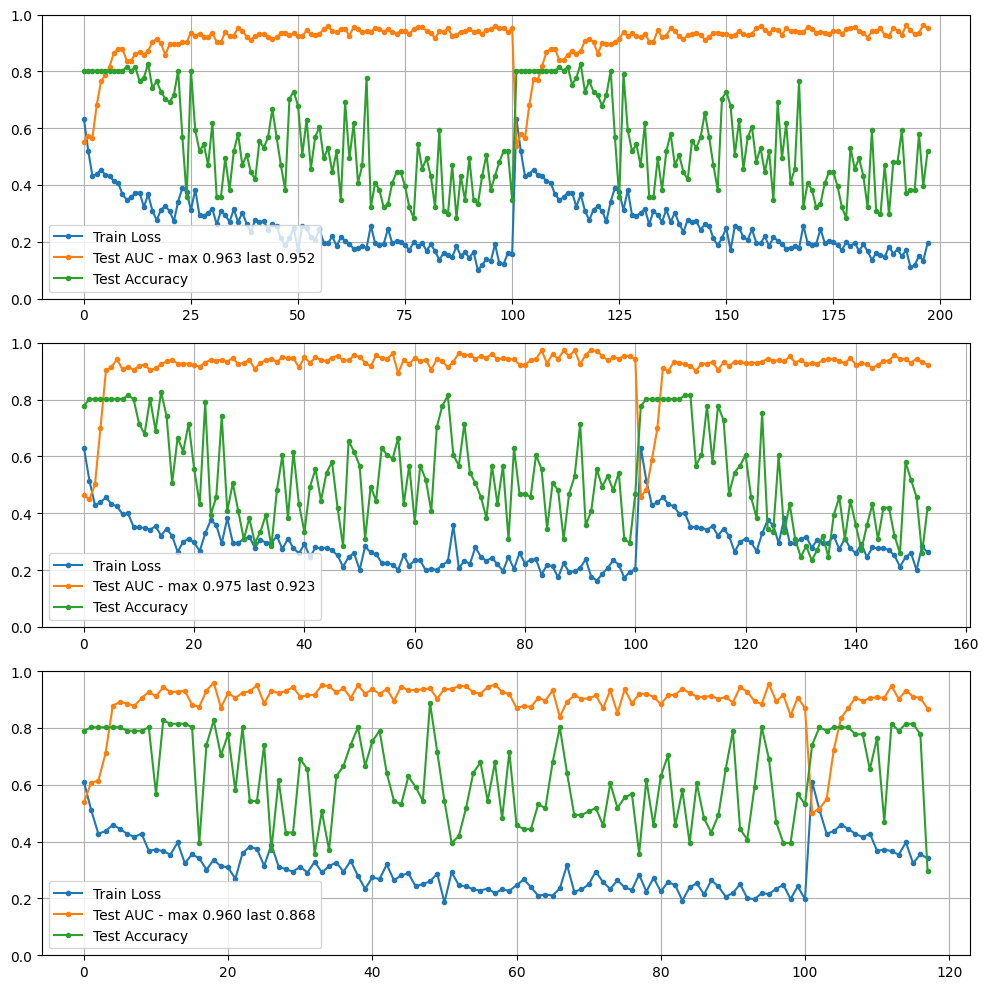

In [4]:
filenames = ['checkpoints_patches/vit_small/Mag1x_Sz256_Imgs64_Tkn32/fold_0/log.txt',
                'checkpoints_patches/vit_small/Mag2x_Sz256_Imgs64_Tkn32/fold_0/log.txt',
             'checkpoints_patches/vit_small/Mag5x_Sz256_Imgs64_Tkn32/fold_0/log.txt']

plt.figure(figsize=(10,10))

for idx, file_path in enumerate(filenames):
    fp=file_path
    
    data_dict = {}
    keys = ["train_loss", 'test_AUC', 'test_ACC']
    for key in keys:
        data_dict[key] = []
    
    if os.path.exists(fp):
        plt.subplot(3,1, idx+1)

        with open(fp, "r") as file:
            for line in file:
                data = json.loads(line)
                for key in keys:
                    if key in data:
                        data_dict[key].append(data[key])
                            
        l_train = np.array(data_dict['train_loss'])
        auc = np.array(data_dict['test_AUC'])
        acc_test = 0.01*np.array(data_dict['test_ACC'])
        # lr_sched = np.array(data_dict['train_lr'])
        
        
        # plt.plot(l_train, label="Train Loss")
        plt.plot(l_train, '.-', label="Train Loss")
        plt.plot(auc, '.-', label="Test AUC - max %.3f last %.3f"%(auc.max(), auc[-1]))
        plt.plot(acc_test, '.-', label="Test Accuracy")
        
        
        plt.ylim([0, 1])
        plt.grid()
        # plt.title('%.0e'%lrs[idx])
        plt.legend()
        
        # plt.subplot(2,5, 5+idx+1)
        # plt.plot(l_train)
        
        
    
plt.tight_layout()
plt.show()

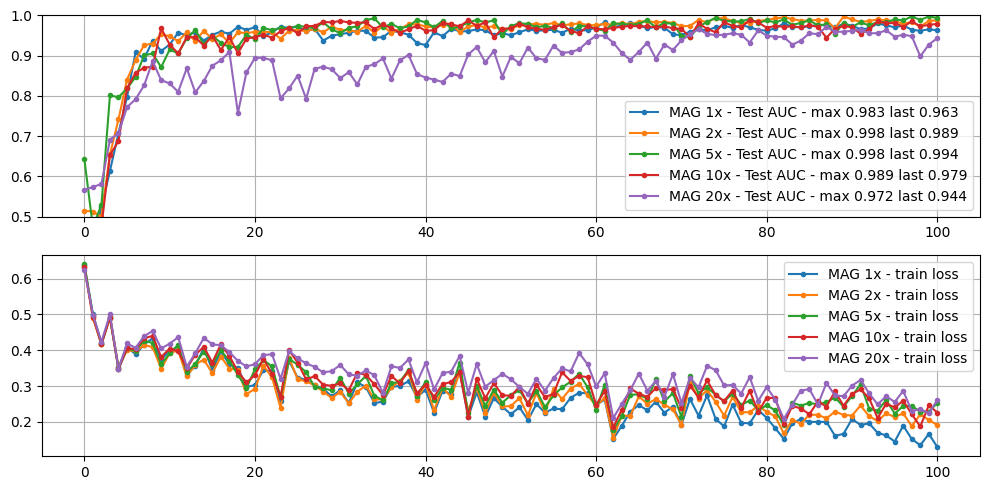

In [4]:

plt.figure(figsize=(10,5))

mags=[1,2,5,10,20]
filenames = ['checkpoints_patches/vit_small/Mag%dx_Sz256_Imgs64_Tkn32/fold_1/log.txt'%i for i in mags]

for idx, file_path in enumerate(filenames):
    

    
    get_auc(fp)
    
    data_dict = {}
    keys = ["train_loss", 'test_AUC', 'test_ACC']
    for key in keys:
        data_dict[key] = []
    
    if os.path.exists(fp):
        # plt.subplot(3,1, idx+1)

        with open(fp, "r") as file:
            for line in file:
                data = json.loads(line)
                for key in keys:
                    if key in data:
                        data_dict[key].append(data[key])
                            
        l_train = np.array(data_dict['train_loss'])
        auc = np.array(data_dict['test_AUC'])
        acc_test = np.array(data_dict['test_ACC'])        

        
        plt.subplot(2,1,1)
        plt.plot(auc, '.-', label="MAG %dx - Test AUC - max %.3f last %.3f"%(mags[idx], auc.max(), auc[-1]))
        
        plt.subplot(2,1,2)
        plt.plot(l_train, '.-', label="MAG %dx - train loss"%mags[idx])
        

plt.subplot(2,1,1)
plt.ylim([0.5, 1])
plt.grid()
# plt.xlim([0, 99])
plt.legend()

plt.subplot(2,1,2)
plt.grid()
# plt.xlim([0, 99])
plt.legend()

        
        # plt.subplot(2,5, 5+idx+1)
        # plt.plot(l_train)
        
        
    
plt.tight_layout()
plt.show()

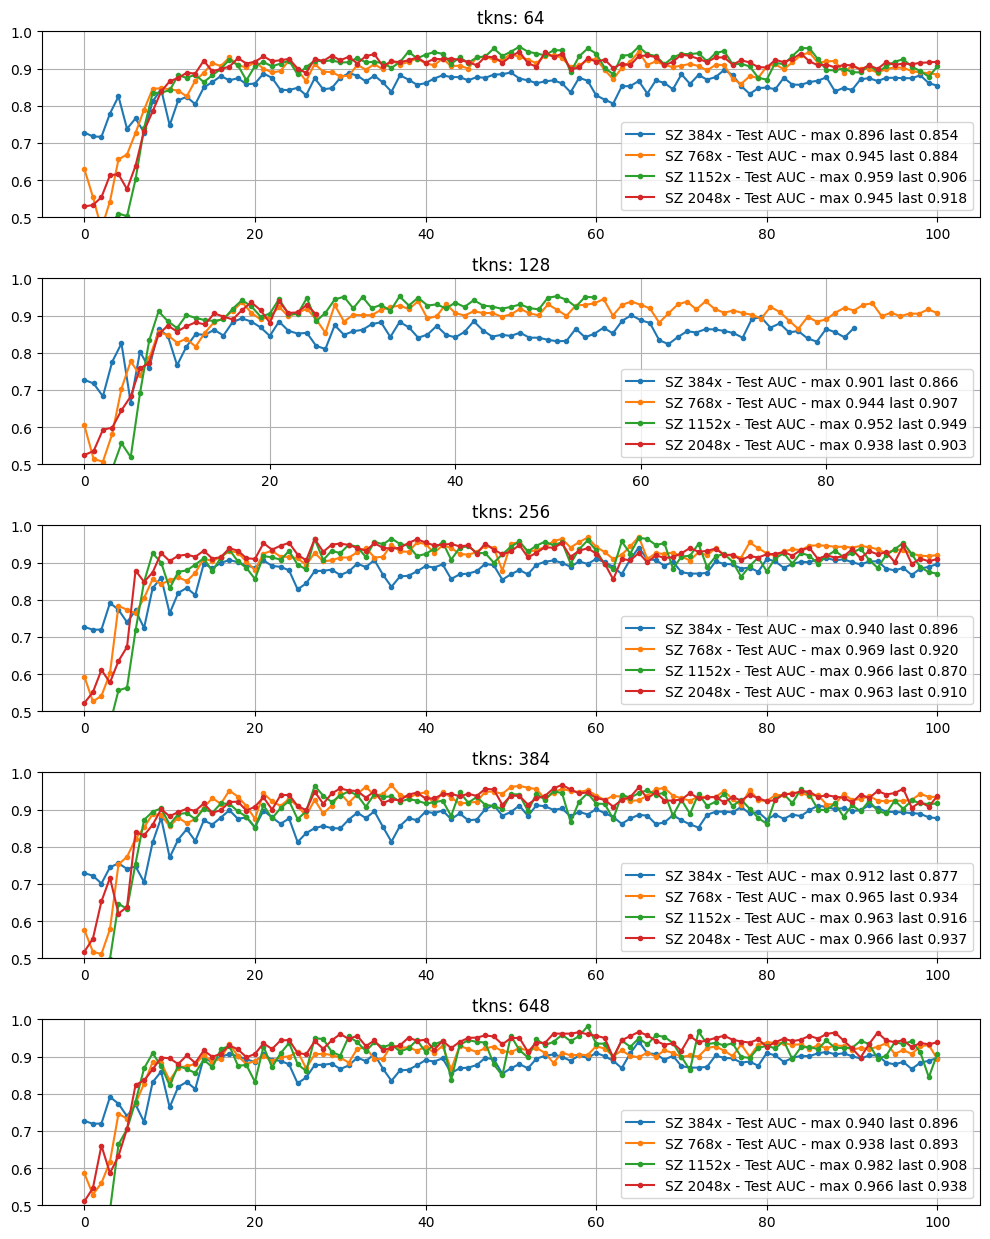

In [5]:


tkns=[64, 128, 256, 384, 648]
szs = [384, 768, 1152, 2048]

file_path = 'checkpoints_images/vit_small/SzSZ_TknTKN/fold_0/log.txt'

plt.figure(figsize=(10, 2.5*len(tkns)))
for idx, tkn in enumerate(tkns):
    fp1=file_path.replace('TKN', '%d'%tkn)
    
    plt.subplot(len(tkns), 1, idx+1)
    
    for aa, sz in enumerate(szs):
        
        fp = fp1.replace('SZ', '%d'%sz)
                
        l_train, auc = get_auc(fp)
   
        plt.plot(auc, '.-', label="SZ %dx - Test AUC - max %.3f last %.3f"%(szs[aa], auc.max(), auc[-1]))

    plt.ylim([0.5, 1])
    plt.grid()
    plt.legend()
    plt.title('tkns: %d'%tkn)


plt.tight_layout()
plt.show()

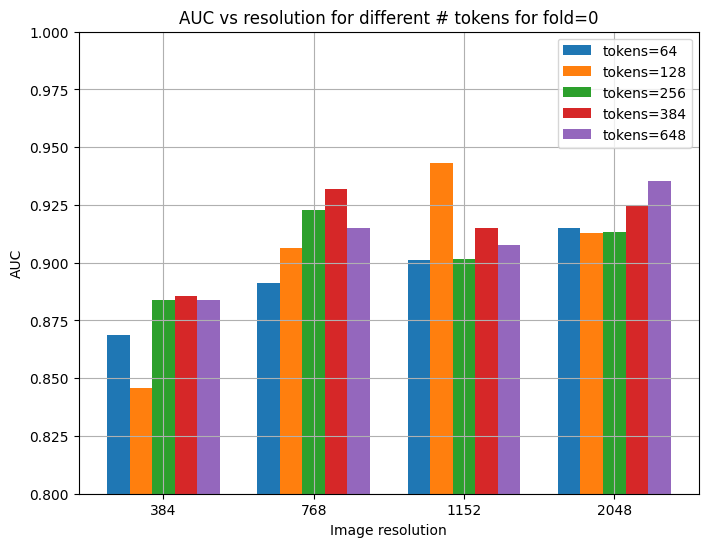

In [4]:

tkns=[64, 128, 256, 384, 648]
szs = [384, 768, 1152, 2048]

file_path = 'checkpoints_images/vit_small/SzSZ_TknTKN/fold_0/log.txt'

# plt.figure(figsize=(10, 2.5*len(tkns)))

aucs = []
for idx, tkn in enumerate(tkns):
    fp1=file_path.replace('TKN', '%d'%tkn)
    
    aaa = []
    for aa, sz in enumerate(szs):
        
        fp = fp1.replace('SZ', '%d'%sz)
                
        l_train, auc = get_auc(fp)
        
        # au = auc[].mean()
        au = auc[-5:].mean()
        aaa.append(au)

    aucs.append(aaa)
    
aucs = np.array(aucs)

bar_width = 0.15
bar_positions = np.arange(len(szs))

plt.figure(figsize=(8, 6))  # Adjust the figure size as needed
plt.grid()
for i, tkn in enumerate(tkns):
    plt.bar(bar_positions + i * bar_width, aucs[i], width=bar_width, label=f'tokens={tkn}')


plt.xlabel('Image resolution')
plt.ylabel('AUC')
plt.title('AUC vs resolution for different # tokens for fold=0')
plt.xticks(bar_positions + (len(tkns) - 1) * bar_width / 2, szs)
plt.ylim([0.8, 1.0])
# plt.grid()
plt.legend()
plt.show()


In [8]:
aucs

array([[0.89114123, 0.93340951, 0.92157944, 0.92421186],
       [0.88903689, 0.93602615, 0.91763084, 0.93505674],
       [0.89114123, 0.91627127, 0.92442465, 0.94288303]])

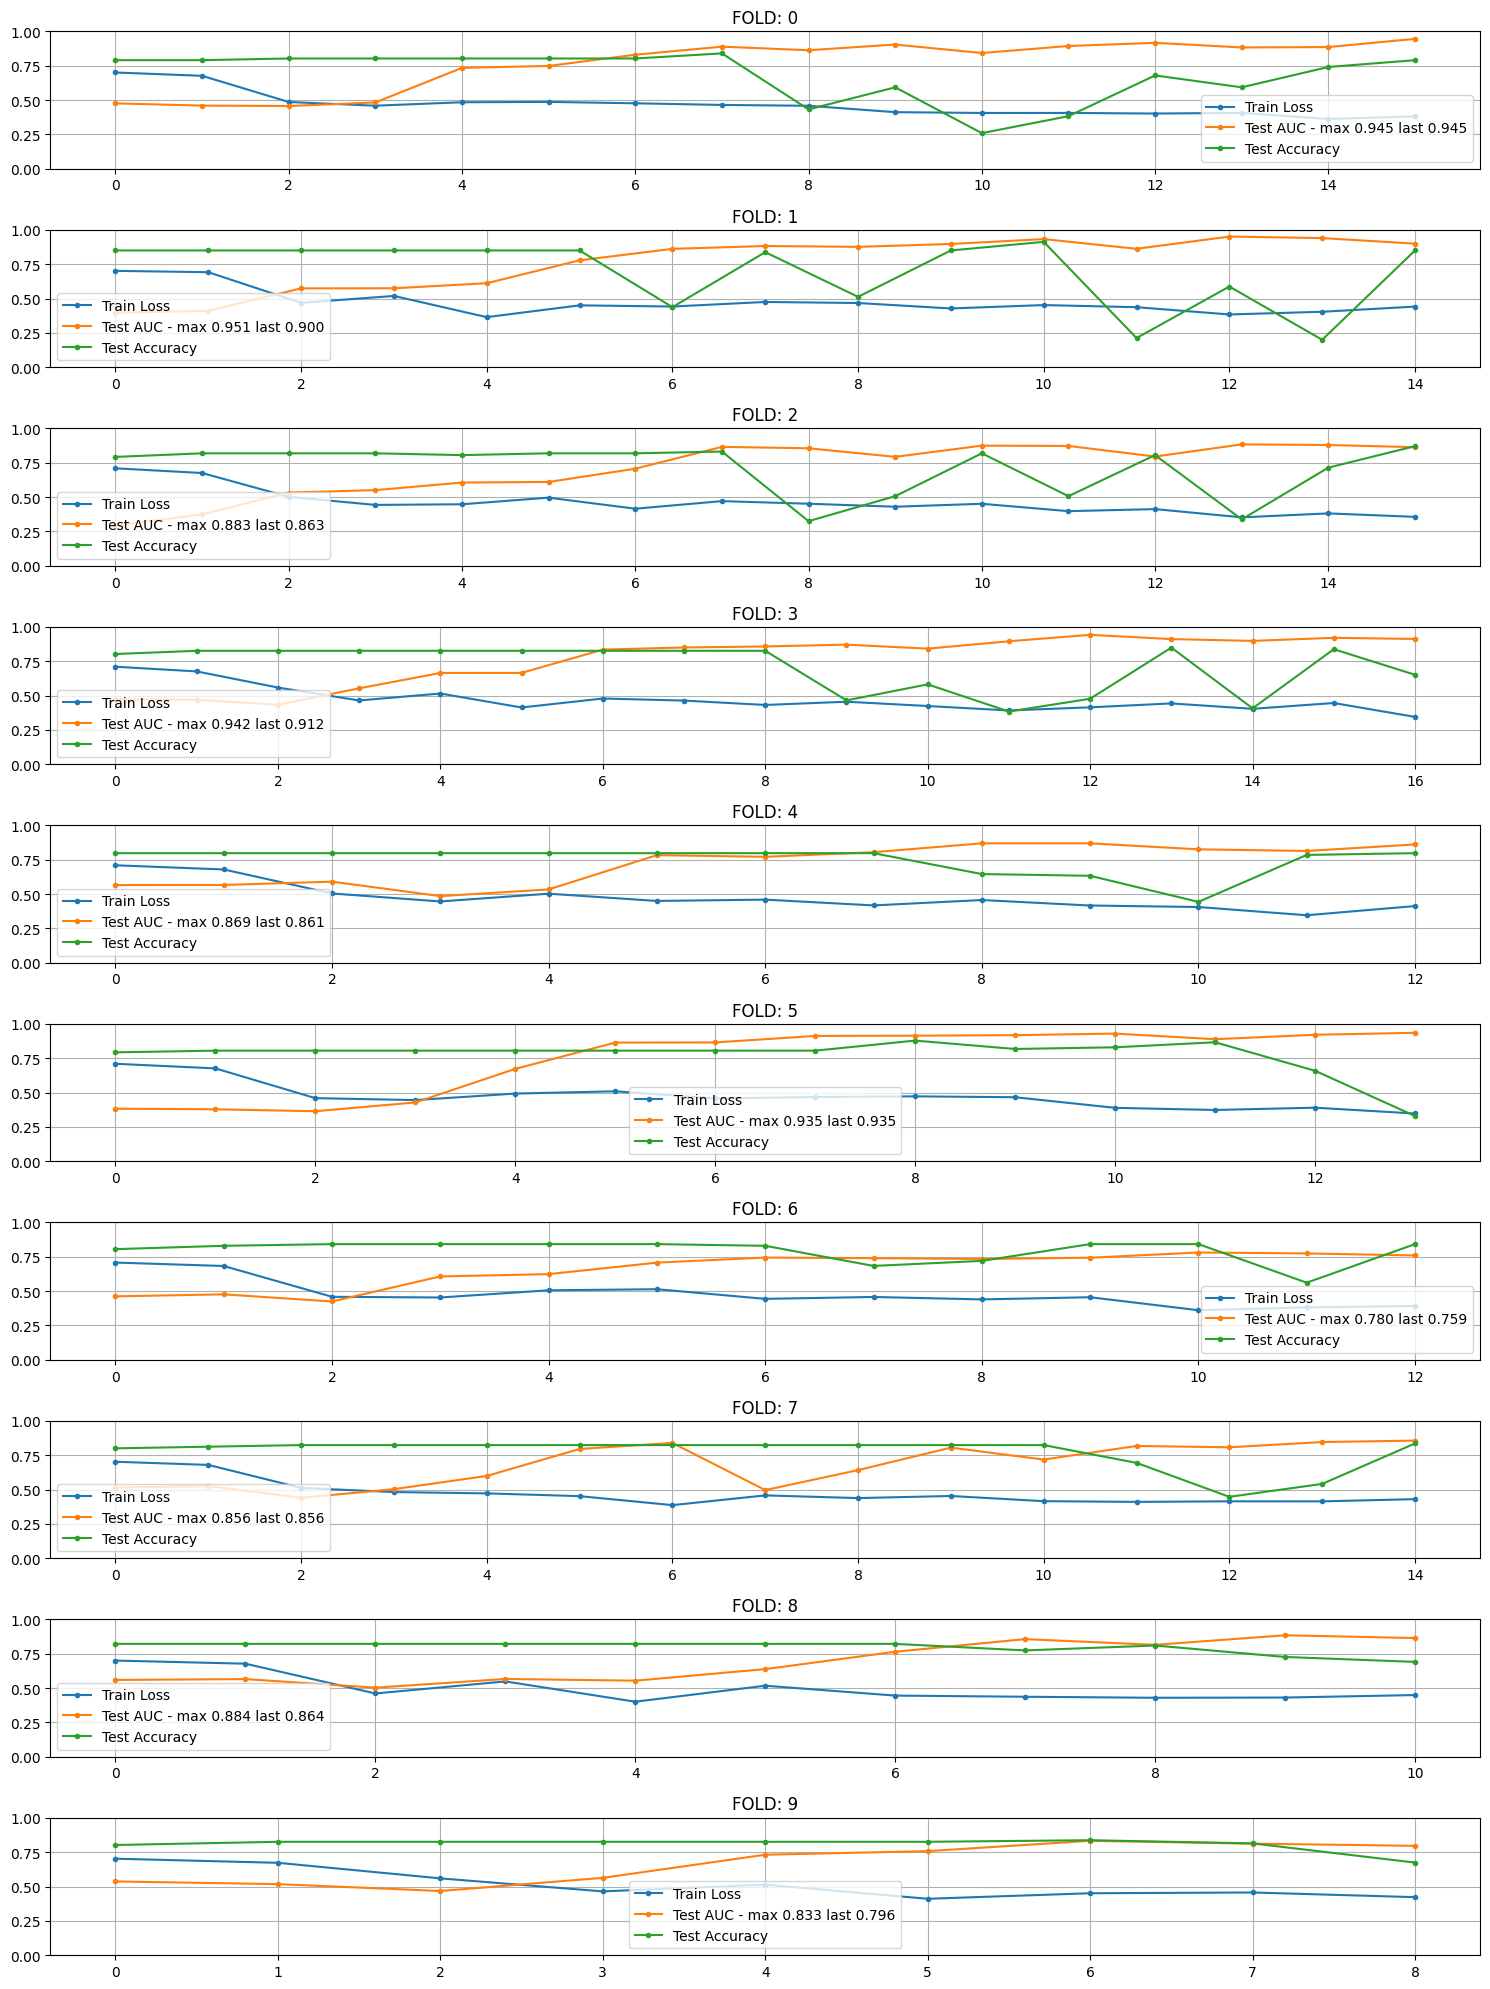

MEAN of all 10 folds: 0.869, STD: 0.055


In [4]:
filenames=['checkpoints_images_512/vit_small/Sz2048_Tkn648/fold_%d/log.txt'%i for i in range(10)]
plt.figure(figsize=(15,20))

accs = []

for idx, file_path in enumerate(filenames):
    fp=file_path
    
    data_dict = {}
    keys = ["train_loss", 'test_AUC', 'test_ACC']
    for key in keys:
        data_dict[key] = []
    
    if os.path.exists(fp):
        plt.subplot(10,1, idx+1)

        with open(fp, "r") as file:
            for line in file:
                data = json.loads(line)
                for key in keys:
                    if key in data:
                        data_dict[key].append(data[key])
                            
        l_train = np.array(data_dict['train_loss'])
        auc = np.array(data_dict['test_AUC'])
        acc_test = 0.01*np.array(data_dict['test_ACC'])
        # lr_sched = np.array(data_dict['train_lr'])
        
        
        # plt.plot(l_train, label="Train Loss")
        plt.plot(l_train, '.-', label="Train Loss")
        plt.plot(auc, '.-', label="Test AUC - max %.3f last %.3f"%(auc.max(), auc[-1]))
        plt.plot(acc_test, '.-', label="Test Accuracy")
        
        
        plt.ylim([0, 1])
        plt.grid()
        plt.title('FOLD: %d'%idx)
        plt.legend()
        
        # accs.append(auc[np.argmin(l_train)])
        accs.append(auc[-1])
        # accs.append(auc.max())
        
plt.tight_layout()
plt.show()

accs = np.array(accs)
print('MEAN of all 10 folds: %.3f, STD: %.3f'%(accs.mean(), accs.std()))

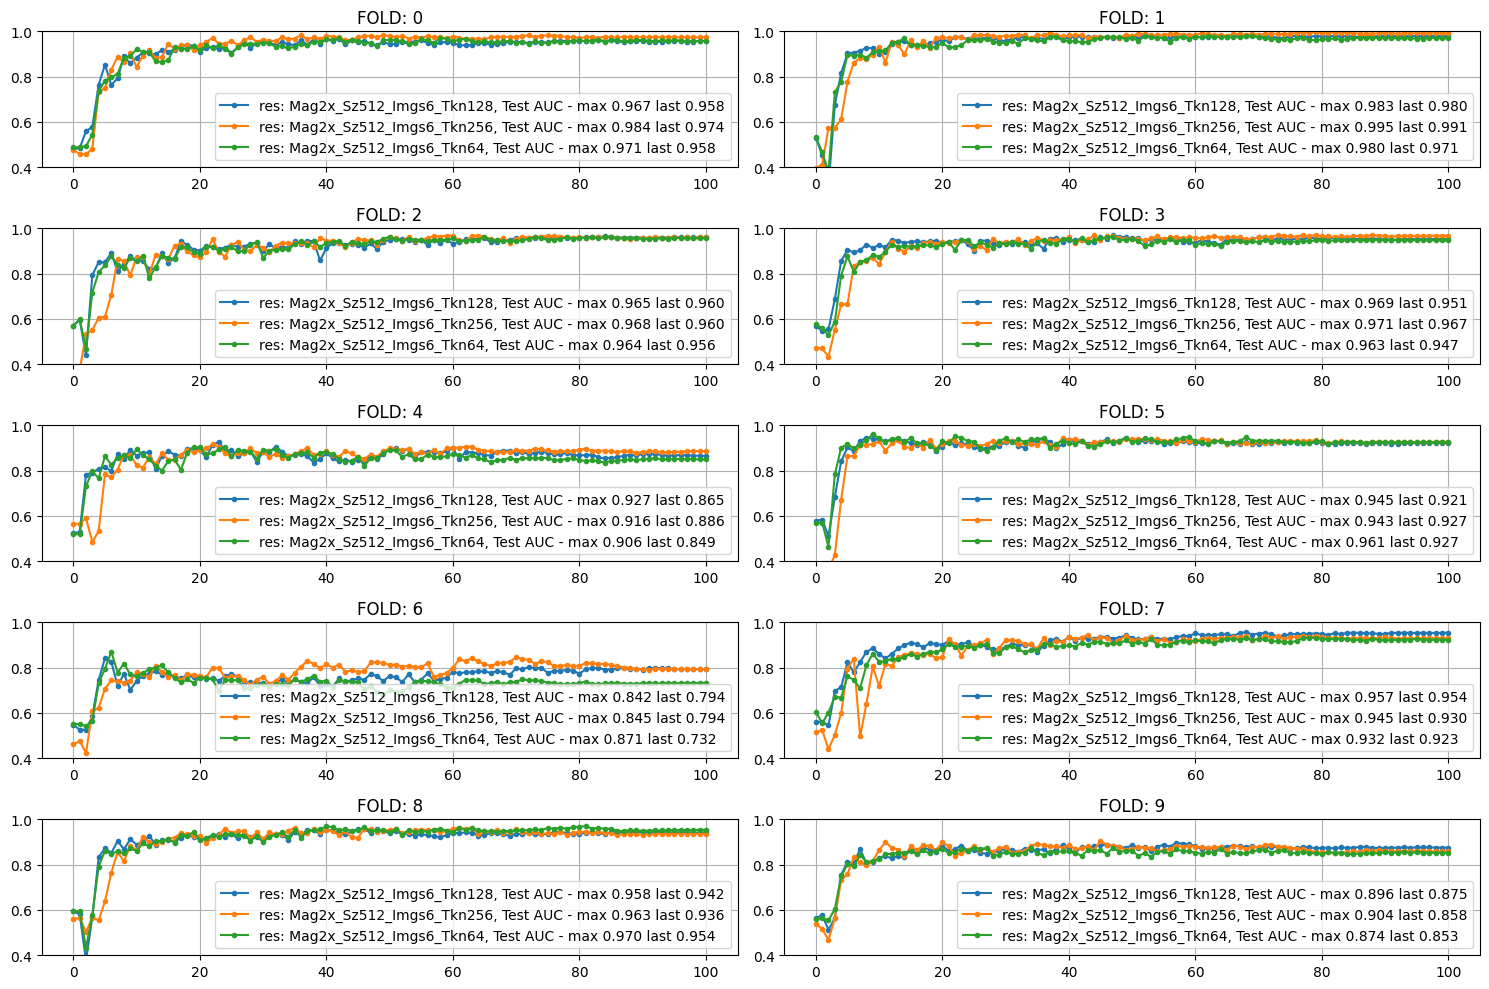

[0.92012455 0.9224117  0.90692745]


In [2]:
filenames=['checkpoints_images_mag/vit_small/NAME/fold_%d/log.txt'%i for i in range(10)]
plt.figure(figsize=(15,10))

accs = []

names = [
        # 'Mag2x_Sz256_Imgs18_Tkn64',
         'Mag2x_Sz512_Imgs6_Tkn128',
         'Mag2x_Sz512_Imgs6_Tkn256',
         'Mag2x_Sz512_Imgs6_Tkn64',
         ]

for idx, file_path in enumerate(filenames):
    plt.subplot(5,2, idx+1)
    
    ac = []
    
    for num in names:
        fp=file_path.replace('NAME', num)
        
        l_train, auc = get_auc(fp)
        
        ac.append(auc[-1])
    
        plt.plot(auc, '.-', label="res: %s, Test AUC - max %.3f last %.3f"%(num, auc.max(), auc[-1]))
        
    accs.append(ac)   
        
    plt.ylim([0.4, 1])
    plt.grid()
    plt.title('FOLD: %d'%idx)
    plt.legend()
        
plt.tight_layout()
plt.show()

accs = np.array(accs)
print(accs.mean(0))

checkpoints_timm_base/vit_base/Sz384_Imgs10_Tkn64/fold_4/log.txt no file!!!!
checkpoints_timm_base/vit_base/Sz384_Imgs10_Tkn64/fold_5/log.txt no file!!!!
checkpoints_timm_base/vit_base/Sz384_Imgs10_Tkn64/fold_6/log.txt no file!!!!
checkpoints_timm_base/vit_base/Sz384_Imgs10_Tkn64/fold_7/log.txt no file!!!!
checkpoints_timm_base/vit_base/Sz384_Imgs10_Tkn64/fold_8/log.txt no file!!!!
checkpoints_timm_base/vit_base/Sz384_Imgs10_Tkn64/fold_9/log.txt no file!!!!


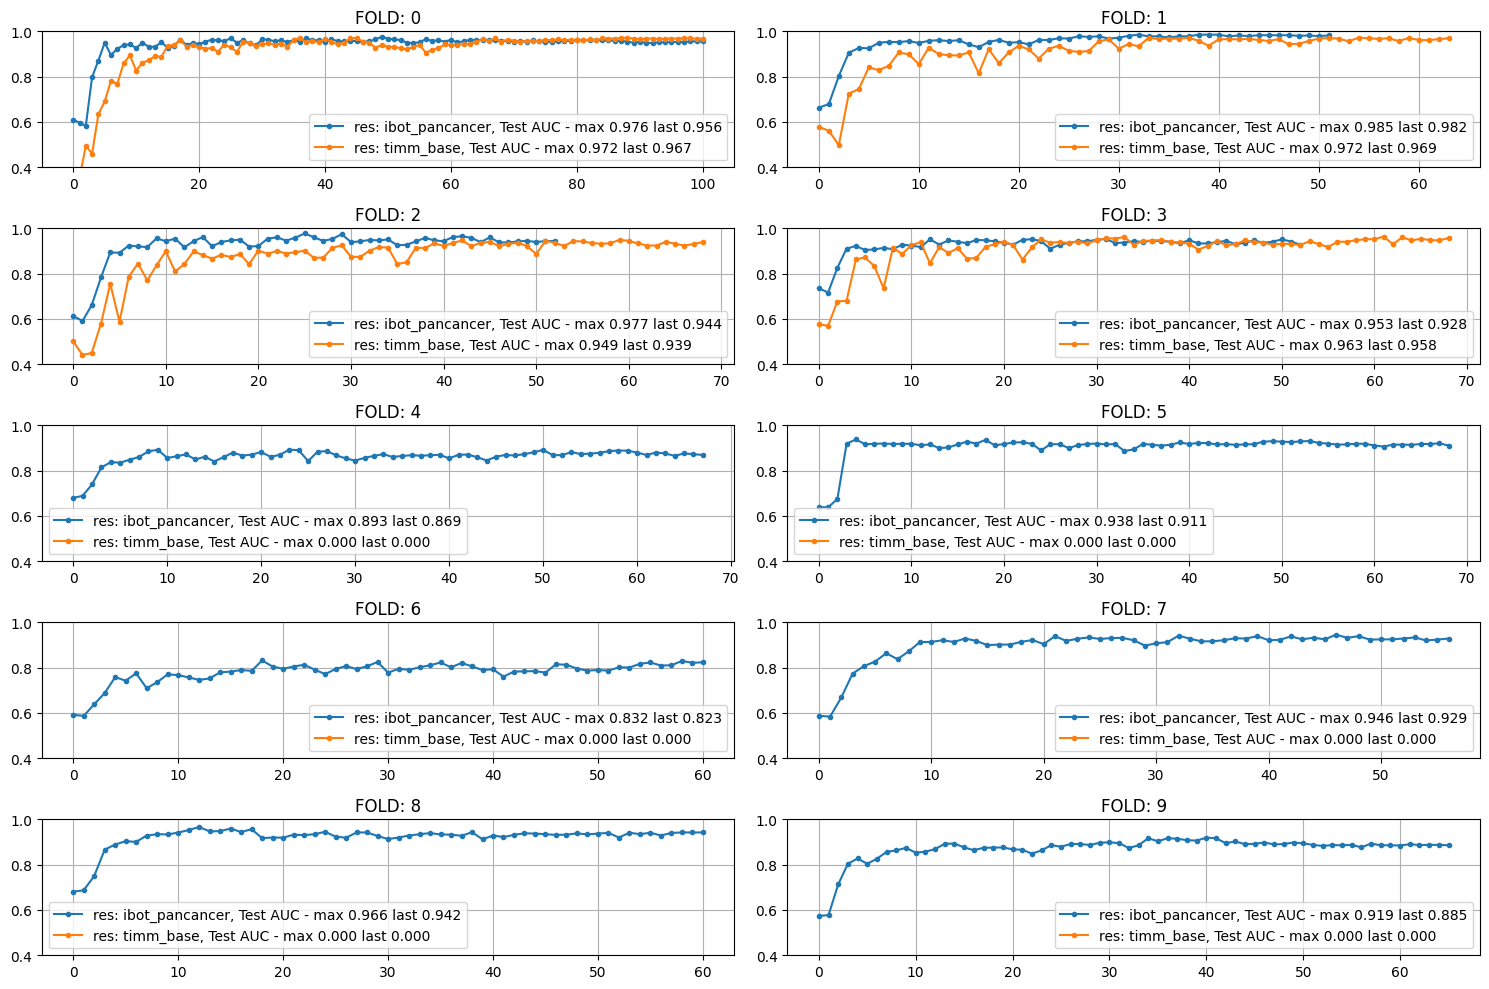

[0.91689097 0.38337593]


In [9]:
filenames=['checkpoints_NAME/vit_base/Sz384_Imgs10_Tkn64/fold_%d/log.txt'%i for i in range(10)]
plt.figure(figsize=(15,10))

accs = []

names = [
        # 'Mag2x_Sz256_Imgs18_Tkn64',
         'ibot_pancancer',
         'timm_base',
         ]

for idx, file_path in enumerate(filenames):
    plt.subplot(5,2, idx+1)
    
    ac = []
    
    for num in names:
        fp=file_path.replace('NAME', num)
        
        l_train, auc = get_auc(fp)
        
        ac.append(auc[-1])
    
        plt.plot(auc, '.-', label="res: %s, Test AUC - max %.3f last %.3f"%(num, auc.max(), auc[-1]))
        
    accs.append(ac)   
        
    plt.ylim([0.4, 1])
    plt.grid()
    plt.title('FOLD: %d'%idx)
    plt.legend()
        
plt.tight_layout()
plt.show()

accs = np.array(accs)
print(accs.mean(0))

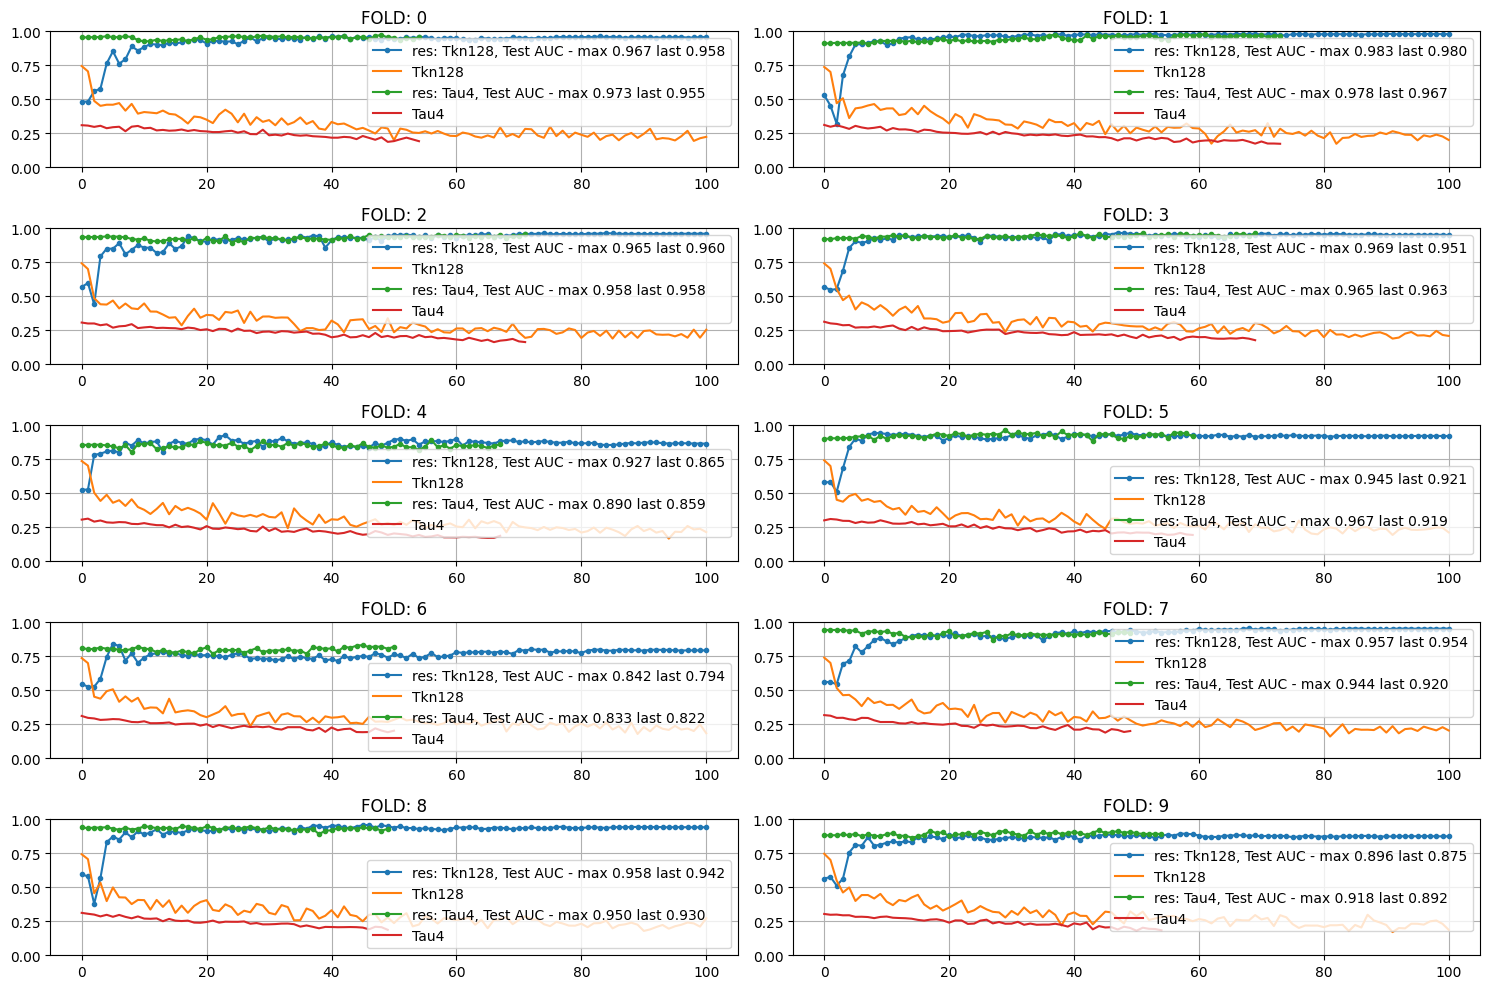

[0.92012455 0.91853946]


In [3]:
filenames=['NAME/fold_%d/log.txt'%i for i in range(10)]
plt.figure(figsize=(15,10))

accs = []

names = [
    'checkpoints_images_mag/vit_small/Mag2x_Sz512_Imgs6_Tkn128',
    'checkpoints_dual_frozen/vit_small/Mag2x_Sz512_Imgs6_Tkn128_Tau4',
    # 'Mag2x_Sz512_Imgs6_Tkn64',
        #  'mag', '3840'
        #  'Mag2x_Sz512_Imgs6_Tkn256',
        #  'Mag2x_Sz256_Imgs18_Tkn64',
         ]

for idx, file_path in enumerate(filenames):
    plt.subplot(5,2, idx+1)
    
    ac = []
    
    for num in names:
        fp=file_path.replace('NAME', num)
        
        l_train, auc = get_auc(fp)
        
        ac.append(auc[-1])

        bb = num.split('/')[-1].split('_')[-1]
    
        plt.plot(auc, '.-', label="res: %s, Test AUC - max %.3f last %.3f"%(bb, auc.max(), auc[-1]))
        plt.plot(l_train, label=bb)
        
    accs.append(ac)   
        
    plt.ylim([0, 1])
    plt.grid()
    plt.title('FOLD: %d'%idx)
    plt.legend()
        
plt.tight_layout()
plt.show()

accs = np.array(accs)
print(accs.mean(0))

checkpoints_images_mag/vit_small/Mag2x_Sz512_Imgs6_Tkn64 0.9069274485111236
checkpoints_images_mag/vit_small/Mag2x_Sz768_Imgs3_Tkn256 0.9299277484416961
checkpoints_images_mag/vit_small/Mag2x_Sz1152_Imgs1_Tkn256 0.9150472521781922
checkpoints_images_mag/vit_small/Mag2x_Sz512_Imgs6_Tkn256 0.9224117040634155
checkpoints_images_mag/vit_small/Mag2x_Sz768_Imgs3_Tkn64 0.9186582446098328
checkpoints_images_mag/vit_small/Mag2x_Sz768_Imgs3_Tkn128 0.9224745988845825
checkpoints_images_mag/vit_small/Mag2x_Sz384_Imgs10_Tkn144 0.9010651886463166
checkpoints_images_mag/vit_small/Mag2x_Sz1152_Imgs1_Tkn128 0.9087710857391358
checkpoints_images_mag/vit_small/Mag2x_Sz512_Imgs6_Tkn128 0.9201245486736298
checkpoints_images_mag/vit_small/Mag2x_Sz1152_Imgs1_Tkn64 0.9071558594703675
checkpoints_images_mag/vit_small/Mag2x_Sz256_Imgs18_Tkn64 0.8870294630527497


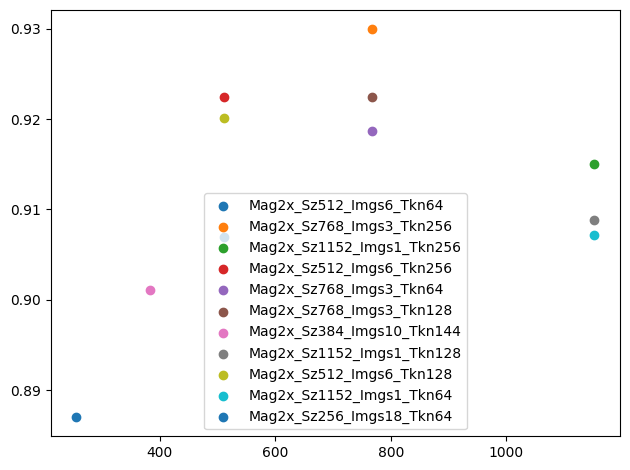

In [16]:
folder_name = 'checkpoints_images_mag/vit_small/'

files = os.listdir(folder_name)

plt.figure()

for fl2 in files:

    fll = os.path.join(folder_name, fl2)
    # print(fl2, fll)

    filenames = ['%s/fold_%d/log.txt'%(fll, i) for i in range(10)]
    # print(filenames)
    ff = int(fl2.split('_')[1][2:])

    aucs = []
    for fp in filenames:
        l_train, auc = get_auc(fp)
        aucs.append(auc[-1])
    
    auc = np.array(aucs).mean()
    print(fll, auc)

    plt.scatter(ff, auc, label=fl2)

plt.legend()
plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

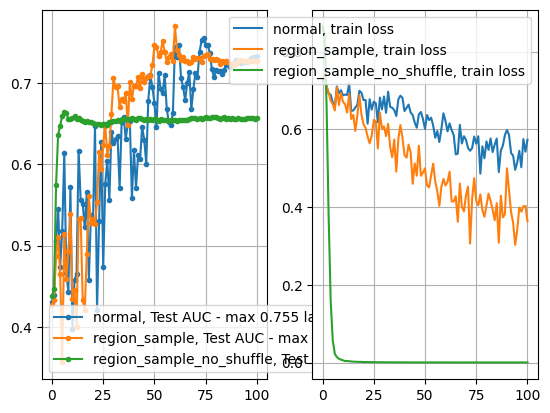

In [9]:
plt.figure(figsize=(8,4))

names = [
    'checkpoints_CAM_timm_small',
    'checkpoints_CAM_attn_timm_small',
    'checkpoints_CAM_attn_noSHUFFLE_timm_small'
         ]

file_path = 'NAME/vit_small/Sz384_Imgs10_Tkn144/fold_4/log.txt'
    
ac = []

namesss = ['normal', 'region_sample', 'region_sample_no_shuffle']

plt.figure()
    
for idx, num in enumerate(names):
    fp=file_path.replace('NAME', num)
    
    l_train, auc = get_auc(fp)
    
    # ac.append(auc[-1])

    nn = namesss[idx]

    bb = num.split('/')[-1].split('_')[-1]

    plt.subplot(1,2,1)

    plt.plot(auc, '.-', label="%s, Test AUC - max %.3f last %.3f"%(nn, auc.max(), auc[-1]))

    plt.subplot(1,2,2)
    plt.plot(l_train, label='%s, train loss'%nn)
        
# accs.append(ac)   
    
# plt.ylim([0, 1])

# plt.title('FOLD: %d'%idx)

for i in range(2):  
    plt.subplot(1,2,i+1)
    plt.grid()
    plt.legend()
        
# plt.tight_layout()
plt.show()



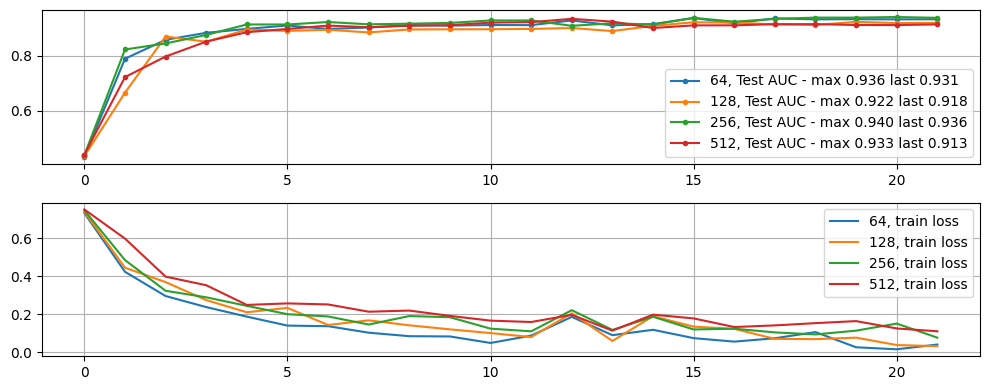

In [2]:
plt.figure(figsize=(10, 4))

mag = 20



names = [
    # # 'Mag5x_Sz256_Imgs64_Tkn32',
    # # 'Mag5x_Sz256_Imgs128_Tkn32',
    # # 'Mag5x_Sz256_Imgs256_Tkn32',
    # # 'Mag5x_Sz256_Imgs512_Tkn32',
    # 'Mag10x_Sz256_Imgs64_Tkn32',
    # 'Mag10x_Sz256_Imgs128_Tkn32',
    # 'Mag10x_Sz256_Imgs256_Tkn32',
    # 'Mag10x_Sz256_Imgs512_Tkn32',
    64,128,256,512

         ]

file_path = 'checkpoints_CAM_ATTN_patches/vit_small/MagMAGx_Sz256_ImgsIMGS_Tkn32/fold_4/log.txt'
    
ac = []

# namesss = ['normal', 'region_sample', 'region_sample_no_shuffle']

# plt.figure()
    
for idx, num in enumerate(names):
    # fp=file_path.replace('NAME', num)

    # fp = 
    fp = file_path.replace('MAG', '%d'%mag).replace('IMGS', '%d'%num)
    
    l_train, auc = get_auc(fp)
    
    # ac.append(auc[-1])

    nn = names[idx]

    # bb = num.split('/')[-1].split('_')[-1]

    plt.subplot(2,1,1)

    auc = auc
    l_train = l_train

    plt.plot(auc, '.-', label="%s, Test AUC - max %.3f last %.3f"%(nn, auc.max(), auc[-1]))

    plt.subplot(2,1,2)
    plt.plot(l_train, label='%s, train loss'%nn)
        
# accs.append(ac)   
    
# plt.ylim([0, 1])

# plt.title('FOLD: %d'%idx)

for i in range(2):  
    plt.subplot(2,1,i+1)
    plt.grid()
    plt.legend()
        
plt.tight_layout()
plt.show()



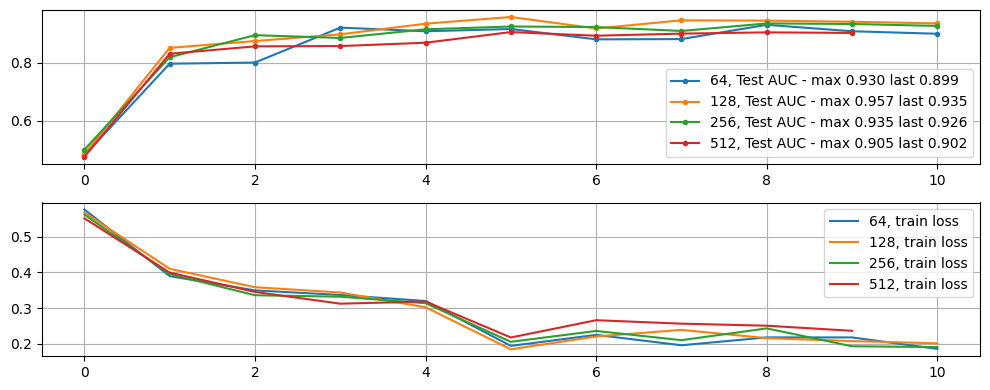

In [8]:
plt.figure(figsize=(10, 4))

mag = 20

names = [
    64,128,256,512
         ]

file_path = 'checkpoints_TCGA_patches/vit_small/MagMAGx_Sz256_ImgsIMGS_Tkn32/fold_0/log.txt'
    
ac = []

# namesss = ['normal', 'region_sample', 'region_sample_no_shuffle']

# plt.figure()
    
for idx, num in enumerate(names):

    fp = file_path.replace('MAG', '%d'%mag).replace('IMGS', '%d'%num)
    
    l_train, auc = get_auc(fp)
    
    nn = names[idx]

    plt.subplot(2,1,1)

    auc = auc
    l_train = l_train

    plt.plot(auc, '.-', label="%s, Test AUC - max %.3f last %.3f"%(nn, auc.max(), auc[-1]))

    plt.subplot(2,1,2)
    plt.plot(l_train, label='%s, train loss'%nn)

for i in range(2):  
    plt.subplot(2,1,i+1)
    plt.grid()
    plt.legend()
        
plt.tight_layout()
plt.show()



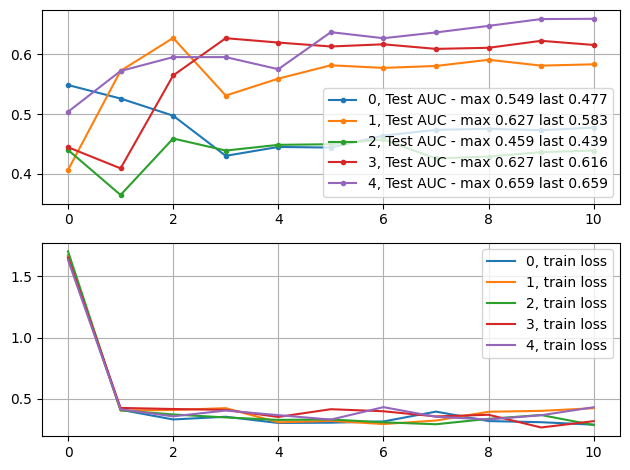

0.5548673872786247 0.08341341886603627


In [19]:
# plt.figure(figsize=(10, 4))

mag = 20

names = list(range(5))

file_path = 'results/tcga_survival/brca/patches/vit_small_patch32_384/Mag20x_Sz256_Imgs128_Tkn32/LR_1e-03/fold_IMGS/log.txt'
    
ac = []

# namesss = ['normal', 'region_sample', 'region_sample_no_shuffle']

# plt.figure()


    
for idx, num in enumerate(names):

    fp = file_path.replace('MAG', '%d'%mag).replace('IMGS', '%d'%num)
    
    l_train, auc = get_auc(fp)

    if auc is not None:
    
        nn = names[idx]

        plt.subplot(2,1,1)

        auc = auc
        l_train = l_train

        ac.append(auc[-1])

        plt.plot(auc, '.-', label="%s, Test AUC - max %.3f last %.3f"%(nn, auc.max(), auc[-1]))

        plt.subplot(2,1,2)
        plt.plot(l_train, label='%s, train loss'%nn)

for i in range(2):  
    plt.subplot(2,1,i+1)
    plt.grid()
    plt.legend()
    
        
plt.tight_layout()
plt.show()

acc = np.array(ac)
print(acc.mean() , acc.std() )


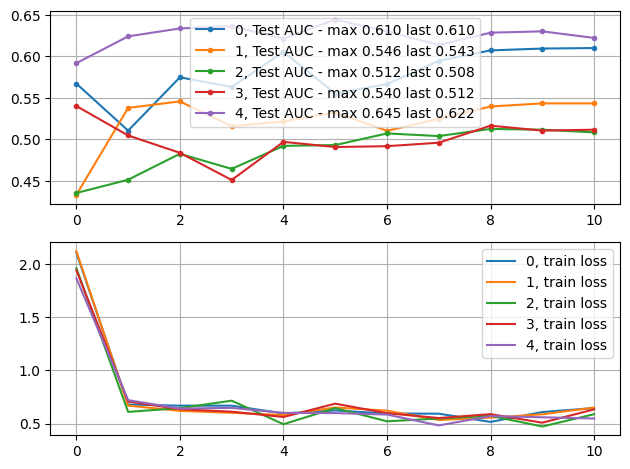

0.5591366466303059 0.048383005678069885


In [4]:
# plt.figure(figsize=(10, 4))

mag = 20

names = list(range(5))

file_path = 'results/tcga_survival/luad/patches_MIL/vit_small/Mag20x_Sz256_Imgs64_Tkn32/fold_IMGS/log.txt'
    
ac = []

# namesss = ['normal', 'region_sample', 'region_sample_no_shuffle']

# plt.figure()


    
for idx, num in enumerate(names):

    fp = file_path.replace('MAG', '%d'%mag).replace('IMGS', '%d'%num)
    
    l_train, auc = get_auc(fp)

    if auc is not None:
    
        nn = names[idx]

        plt.subplot(2,1,1)

        auc = auc
        l_train = l_train

        ac.append(auc[-1])

        plt.plot(auc, '.-', label="%s, Test AUC - max %.3f last %.3f"%(nn, auc.max(), auc[-1]))

        plt.subplot(2,1,2)
        plt.plot(l_train, label='%s, train loss'%nn)

for i in range(2):  
    plt.subplot(2,1,i+1)
    plt.grid()
    plt.legend()
    
        
plt.tight_layout()
plt.show()

acc = np.array(ac)
print(acc.mean() , acc.std() )



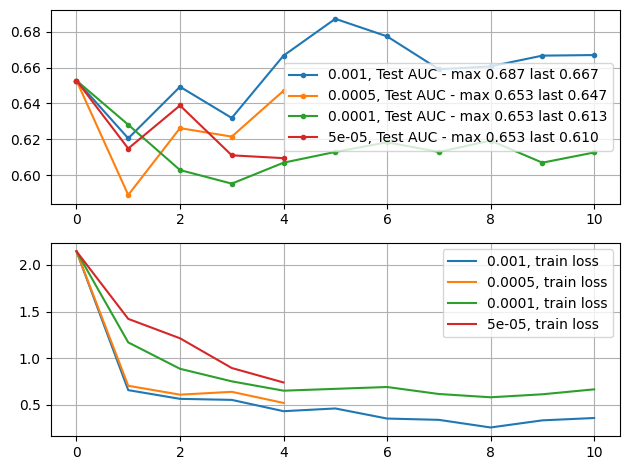

0.6340751262626263 0.02404214866763688


In [18]:
# plt.figure(figsize=(10, 4))

mag = 20

names = [1e-3, 5e-4, 1e-4, 5e-5]



file_path = 'results/tcga_survival/luad/patches/vit_base_patch16_224.owkin_pancancer/Mag20x_Sz224_Imgs64_Tkn64/LR_lr/fold_0/log.txt'
    
ac = []

# namesss = ['normal', 'region_sample', 'region_sample_no_shuffle']

# plt.figure()


    
for idx, num in enumerate(names):

    fp = file_path.replace('MAG', '%d'%mag).replace('lr', '%.0e'%num)
    
    l_train, auc = get_auc(fp)

    if auc is not None:
    
        nn = names[idx]

        plt.subplot(2,1,1)

        auc = auc
        l_train = l_train

        ac.append(auc[-1])

        plt.plot(auc, '.-', label="%s, Test AUC - max %.3f last %.3f"%(nn, auc.max(), auc[-1]))

        plt.subplot(2,1,2)
        plt.plot(l_train, label='%s, train loss'%nn)

for i in range(2):  
    plt.subplot(2,1,i+1)
    plt.grid()
    plt.legend()
    
        
plt.tight_layout()
plt.show()

acc = np.array(ac)
print(acc.mean() , acc.std() )



In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import json

def get_auc(fp):
    
    data_dict = {}
    keys = ["train_loss", 'test_AUC', 'test_ACC']
    for key in keys:
        data_dict[key] = []
    
    if os.path.exists(fp):
        # plt.subplot(3,1, idx+1)

        with open(fp, "r") as file:
            for line in file:
                data = json.loads(line)
                for key in keys:
                    if key in data:
                        data_dict[key].append(data[key])
                            
        l_train = np.array(data_dict['train_loss'])
        auc = np.array(data_dict['test_AUC'])
        
    else:
        print(fp, 'no file!!!!')
        l_train = None
        auc=None
            
    
    return l_train, auc